## Problem Statement

---
Using a Transformer architecture, forecast the intensity and track (latitude, longitude) of tropical cyclones.

## Data Description

---
The dataset consists of cyclone trajectory records stored in CSV
files. Each file contains time-series observations such as:
- Latitude
- Longitude
- Wind speed / intensity

The task is a sequence-to-sequence regression problem:   
Given past timesteps → predict future intensity and track.

## Model description

---
A Transformer-based model is used for sequence modeling.

Key Components:
- Positional Encoding (to retain sequence order)
- Multi-head Self Attention (captures temporal dependencies)
- Feed Forward Network

Output:
- Regression outputs: [latitude, longitude, intensity]

Import required libraries

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

c:\Users\DS-31\Biswa_PG\.Rup\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Data loader class

In [2]:
class DataLoader:

    def __init__(self, path):
        self.path = path

    def load_data(self):

        files = [os.path.join(self.path, f)
                 for f in os.listdir(self.path)
                 if f.endswith(".csv")]

        dfs = []
        for f in files:
            df = pd.read_csv(f)
            cols = df.columns.str.lower() # detect columns

            # Latitude & Longitude
            lat_col = [c for c in df.columns if "lat" in c.lower()][0]
            lon_col = [c for c in df.columns if "lon" in c.lower()][0]

            # Intensity (cyclone datasets use different names)
            wind_candidates = [
                c for c in df.columns
                if any(k in c.lower() for k in
                       ["wind", "msw", "vmax", "speed"])
            ]

            if len(wind_candidates) == 0:
                raise ValueError(f"No wind/intensity column in {f}")

            wind_col = wind_candidates[0]

            # Time column 
            time_candidates = [
                c for c in df.columns
                if any(k in c.lower() for k in
                       ["time", "date"])
            ]

            time_col = time_candidates[0]

            # ----------- CLEAN + SELECT ----------------
            temp = df[[time_col, lat_col, lon_col, wind_col]].copy()
            temp.columns = ["TIME", "LAT", "LON", "WIND"]

            # Convert time and sort
            temp["TIME"] = pd.to_datetime(temp["TIME"], errors='coerce')
            temp = temp.sort_values("TIME")

            # Drop missing values
            temp = temp.dropna()

            dfs.append(temp)

        # Combine all cyclones
        full_df = pd.concat(dfs, ignore_index=True)

        return full_df

    def preprocess(self, df, seq_len=10):

        # Normalize features
        features = ["LAT", "LON", "WIND"]

        self.mean = df[features].mean()
        self.std = df[features].std()

        df[features] = (df[features] - self.mean) / self.std

        # Create sequences
        X, y = [], []

        values = df[features].values

        for i in range(len(values) - seq_len):
            X.append(values[i:i+seq_len])
            y.append(values[i+seq_len])  # next timestep

        return np.array(X), np.array(y)

Transformer model class

In [3]:
class TransformerModel:

    def __init__(self, input_shape):

        inputs = layers.Input(shape=input_shape)

        # Multi-head attention
        attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
        x = layers.Add()([inputs, attn])
        x = layers.LayerNormalization()(x)

        # Feed forward network
        ff = layers.Dense(256, activation='relu')(x)
        ff = layers.Dense(input_shape[-1])(ff)

        x = layers.Add()([x, ff])
        x = layers.LayerNormalization()(x)

        # Output layer (last timestep)
        x = layers.GlobalAveragePooling1D()(x)
        outputs = layers.Dense(3)(x)  # lat, lon, intensity

        self.model = models.Model(inputs, outputs)

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='mse',
            metrics=['mae']
        )

    def train(self, X, y):
        return self.model.fit(X, y, batch_size=batch_size, epochs=epochs)

    def evaluate(self, X, y):
        return self.model.evaluate(X, y)

Train plotting

In [8]:
import matplotlib.pyplot as plt

def plot_history(history):

    # -------- LOSS --------
    plt.figure(figsize=(10,5))
    plt.plot(history.history['loss'], label='Train Loss')
    # plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    # -------- MAE --------
    plt.figure(figsize=(10,5))
    plt.plot(history.history['mae'], label='Train MAE')
    # plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title("MAE Curve")
    plt.xlabel("Epochs")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid()
    plt.show()

Experiment pipeline with evaluation

In [5]:
class Experiment:

    def __init__(self):
        self.loader = DataLoader(data_path)

    def run(self):

        # Load data
        df = self.loader.load_data()

        # Preprocess
        X, y = self.loader.preprocess(df)

        # Train-test split
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # Model
        model = TransformerModel(input_shape=X_train.shape[1:])

        # Train
        history = model.train(X_train, y_train)
        plot_history(history)

        # Evaluate
        train_loss, train_mae = model.evaluate(X_train,y_train)
        test_loss, test_mae = model.evaluate(X_test, y_test)
        
        print("\n\nTrain Loss:", train_loss)
        print("Train MAE:", train_mae)

        print("\nTest Loss:", test_loss)
        print("Test MAE:", test_mae)

In [6]:
seq_length = 10
batch_size = 32
epochs = 25
learning_rate = 0.0005
data_path = r"C:\Users\DS-31\Biswa_PG\Biswa_PG4\DL\attachments"   

Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5824 - mae: 1.0023
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7720 - mae: 0.6533
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5743 - mae: 0.5864
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5061 - mae: 0.5399
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4909 - mae: 0.5246
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4817 - mae: 0.5173
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4747 - mae: 0.5116
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4679 - mae: 0.5035
Epoch 9/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4625 - mae: 0.5003
Epoch 10/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4567 - mae: 0.4967
Epoch 11/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4511 - mae: 0.4935
Epoch 12/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4466 - mae: 0.4889
Epoch 13/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

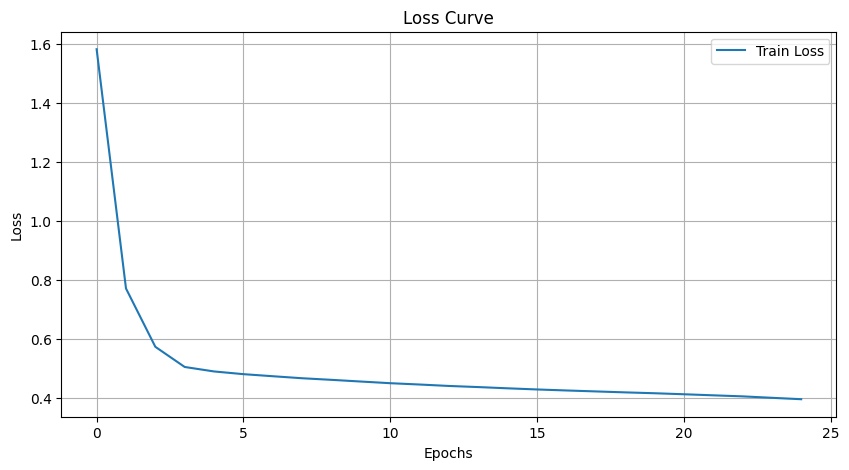

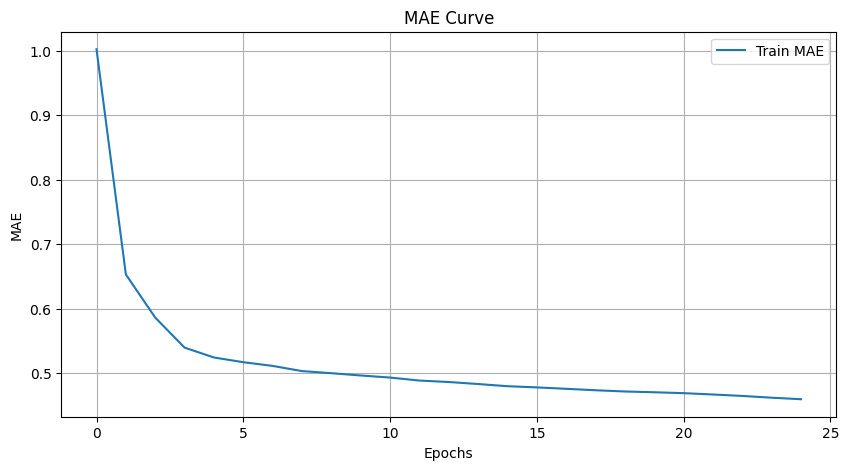

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3933 - mae: 0.4581  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1433 - mae: 0.3127 


Train Loss: 0.3933357000350952
Train MAE: 0.458068311214447

Test Loss: 0.143268883228302
Test MAE: 0.3127271234989166


In [9]:
code = Experiment()
code.run()